In [57]:
import pandas as pd
import numpy as np
import glob
from scipy.stats import norm
import itertools
import matplotlib.pyplot as plt

In [39]:
phenotype_heritability = {
    "50_irnt": 0.772285427,
    "102_irnt": 0.178686544,
    "3148_irnt": 0.339364293,
    "30010_irnt": 0.292565936,
    "30090_irnt": 0.321308299,
    "30100_irnt": 0.437768418,
    "30180_irnt": 0.236670105,
    "30190_irnt": 0.248213462,
    "30210_irnt": 0.269227784,
    "30290_irnt": 0.220529422
}

In [40]:
ancestry = ["ceu", "chb", "jpt", "yri"]

In [41]:
def obtain_file(phenotype, ancestry):
    path = f"data/final_pgs_result/phenotype_{phenotype}/genomewide_{ancestry.lower()}_phenotype_{phenotype}.csv"
    return path

In [42]:
def obtain_total_phenotype(df, h2):
    env_var = (1 - h2) / h2 * np.var(df["genetic_value"])
    df["environment"] = np.random.normal(
        loc=0, scale=np.sqrt(env_var), size=len(df)
    )

    df["phenotype"] = df["genetic_value"] + df["environment"]

    df["phenotype_rank"] = df["phenotype"].rank()
    df["rank-normal-transform"] = df["phenotype_rank"].apply(
        lambda x: norm.ppf((x - 3 / 8) / (len(df) - 2 * 3 / 8 + 1))
    )

    return df

In [43]:
def calc_r2(phenotype, pgs):
    r = np.corrcoef(phenotype, pgs)[0, 1]
    return r ** 2

In [44]:
def calc_pgs_r2(phenotype, ancestry):
    filename = obtain_file(phenotype, ancestry)
    df = pd.read_csv(filename)
    df = obtain_total_phenotype(df, h2=phenotype_heritability[phenotype])

    phenotype_r2 = calc_r2(df["SCORE1_AVG"], df["phenotype"])
    rank_r2 = calc_r2(df["SCORE1_AVG"], df["rank-normal-transform"])

    return phenotype_r2, rank_r2

In [45]:
result_dict = {
    "ancestry": [],
    "phenotype": [],
    "phenotype_r2": [],
    "rank_r2": []
}

In [46]:
for data in itertools.product(list(phenotype_heritability), ancestry):
    phenotype_r2, rank_r2 = calc_pgs_r2(phenotype=data[0], ancestry=data[1])

    result_dict["phenotype"].append(data[0])
    result_dict["ancestry"].append(data[1])
    result_dict["phenotype_r2"].append(phenotype_r2)
    result_dict["rank_r2"].append(rank_r2)

In [47]:
result_df = pd.DataFrame(result_dict)

In [49]:
result_df.head()

,ancestry,phenotype,phenotype_r2,rank_r2
0,ceu,50_irnt,0.355241,0.355355
1,chb,50_irnt,0.247315,0.247188
2,jpt,50_irnt,0.251865,0.251773
3,yri,50_irnt,0.077425,0.077437
4,ceu,102_irnt,0.060309,0.060288


In [50]:
ceu_r2 = (
    result_df[result_df["ancestry"] == "ceu"]
    .set_index("phenotype")["phenotype_r2"]
)

result_df["relative_accuracy"] = (
    result_df["phenotype_r2"]
    / result_df["phenotype"].map(ceu_r2)
)

result_df["relative_accuracy_percent"] = (
    result_df["relative_accuracy"] * 100
)

In [51]:
result_df.head()

,ancestry,phenotype,phenotype_r2,rank_r2,relative_accuracy,relative_accuracy_percent
0,ceu,50_irnt,0.355241,0.355355,1.000000,100.000000
1,chb,50_irnt,0.247315,0.247188,0.696190,69.618963
2,jpt,50_irnt,0.251865,0.251773,0.708997,70.899719
3,yri,50_irnt,0.077425,0.077437,0.217950,21.794981
4,ceu,102_irnt,0.060309,0.060288,1.000000,100.000000


In [55]:
phenotype_label = {
    "50_irnt": "Standing height",
    "102_irnt": "Pulse rate, automated reading",
    "3148_irnt": "Heel bone mineral density (BMD)",
    "30010_irnt": "Red blood cell (erythrocyte) count",
    "30090_irnt": "Platelet crit",
    "30100_irnt": "Mean platelet (thrombocyte) volume",
    "30180_irnt": "Lymphocyte percentage",
    "30190_irnt": "Monocyte percentage",
    "30210_irnt": "Eosinophill percentage",
    "30290_irnt": "High light scatter reticulocyte percentage",
}

In [77]:
figure_label = {
    "50_irnt": "Standing Height",
    "30100_irnt": "Mean Platelet Volume",
    "30090_irnt": "Platelet Crit",
    "30210_irnt": "Eosinophill Percentage",
    "30010_irnt": "Red Blood Cell Count",
    "30190_irnt": "Monocyte Percentage",
}

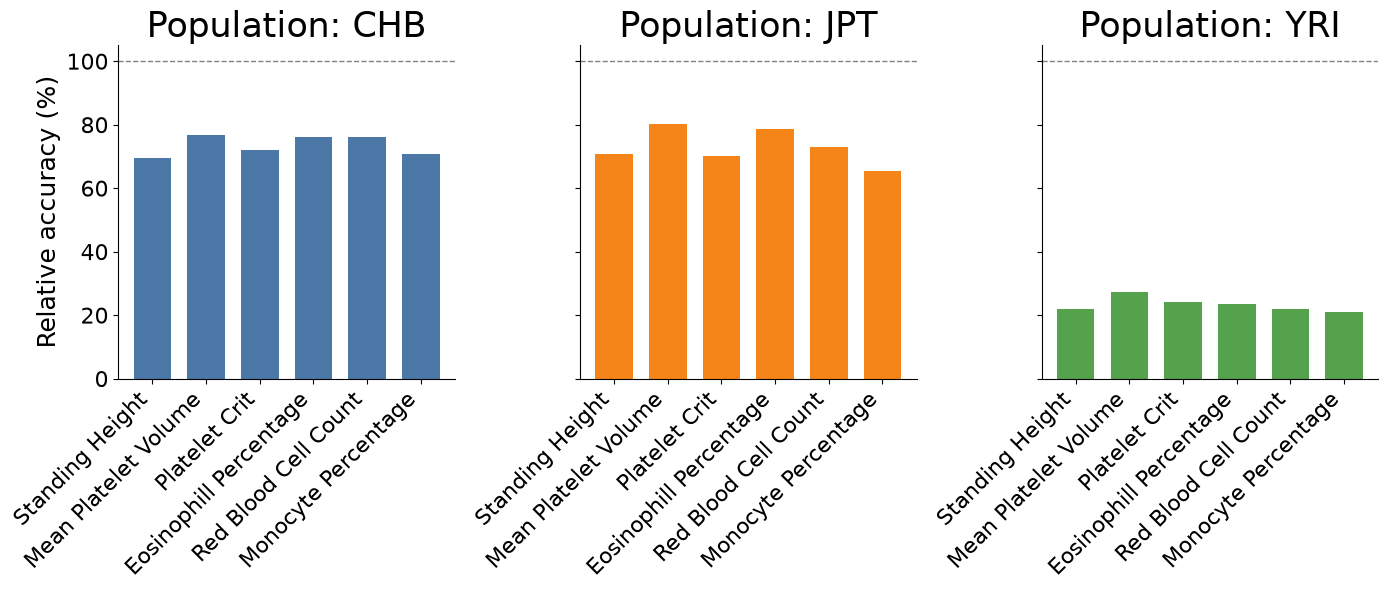

In [84]:
ancestries = ["chb", "jpt", "yri"]

ancestry_colors = {
    "chb": "#4C78A8",
    "jpt": "#F58518",
    "yri": "#54A24B",
}

phenotype_order = list(figure_label.keys())

fig, axes = plt.subplots(
    1, 3,
    figsize=(14, 6),
    sharey=True
)

for ax, ancestry in zip(axes, ancestries):

    tmp = result_df[
        (result_df["ancestry"] == ancestry)
        & (result_df["phenotype"].isin(phenotype_order))
    ].copy()

    tmp["phenotype"] = pd.Categorical(
        tmp["phenotype"],
        categories=phenotype_order,
        ordered=True
    )

    tmp = tmp.sort_values("phenotype")

    x = np.arange(len(tmp))

    ax.bar(
        x,
        tmp["relative_accuracy_percent"],
        color=ancestry_colors[ancestry],
        width=0.7
    )

    ax.set_xticks(x)


    ax.set_xticklabels(
        [figure_label[p] for p in tmp["phenotype"]],
        rotation=45,
        ha="right",
        fontsize=16
    )

    ax.set_title(
        f"Population: {ancestry.upper()}",
        fontsize=25
    )

    # CEU reference
    ax.axhline(
        100,
        linestyle="--",
        linewidth=1,
        color="grey"
    )

    ax.set_ylim(0, 105)
    ax.tick_params(
    axis="y",
    labelsize=16
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(
    "Relative accuracy (%)",
    fontsize=18
)
plt.tight_layout()
plt.savefig("pgs-portability.pdf")
plt.show()